In [1]:

# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')


In [3]:

import pandas as pd

df = pd.read_csv(
    'bank+marketing/bank/bank-full.csv',
    sep=';'
)

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:

# Informações gerais
df.info()

# Valores nulos
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

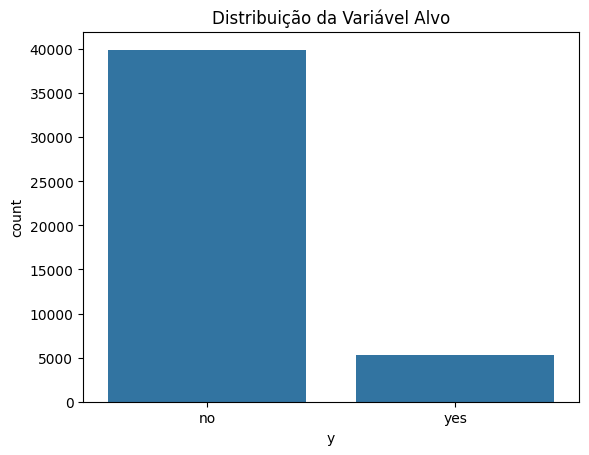

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [5]:

# Distribuição da variável alvo
sns.countplot(x='y', data=df)
plt.title('Distribuição da Variável Alvo')
plt.show()

df['y'].value_counts(normalize=True) * 100



A base é desbalanceada, pois a maioria dos clientes não aderiu à campanha de marketing.
Por isso, além da acurácia, serão utilizadas métricas como precisão, recall e F1-score.


In [6]:

# Transformando variáveis categóricas
le = LabelEncoder()

for coluna in df.select_dtypes(include='object').columns:
    df[coluna] = le.fit_transform(df[coluna])

# Separando variáveis
X = df.drop('y', axis=1)
y = df['y']

# Divisão treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(31647, 16)
(13564, 16)


In [7]:

# Pipeline
pipeline_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# Treinamento
pipeline_base.fit(X_train, y_train)

# Previsões
y_pred_base = pipeline_base.predict(X_test)

# Métricas
acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print("Acurácia:", acc_base)
print("Precisão:", prec_base)
print("Recall:", rec_base)
print("F1-score:", f1_base)


Acurácia: 0.8911825420230021
Precisão: 0.5958549222797928
Recall: 0.21739130434782608
F1-score: 0.3185595567867036


In [8]:

# Definindo hiperparâmetros
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__penalty': ['l2']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Executando busca
grid_search.fit(X_train, y_train)

# Melhores parâmetros
print("Melhores parâmetros:")
print(grid_search.best_params_)

print("\nMelhor F1-score:")
print(grid_search.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Melhores parâmetros:
{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Melhor F1-score:
0.31843767759176234


In [9]:

# Melhor modelo
best_model = grid_search.best_estimator_

# Previsões
y_pred_best = best_model.predict(X_test)

# Probabilidades
y_prob = best_model.predict_proba(X_test)[:,1]

# Métricas
acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print("Acurácia:", acc_best)
print("Precisão:", prec_best)
print("Recall:", rec_best)
print("F1-score:", f1_best)

print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred_best))


Acurácia: 0.8911825420230021
Precisão: 0.5958549222797928
Recall: 0.21739130434782608
F1-score: 0.3185595567867036

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     11977
           1       0.60      0.22      0.32      1587

    accuracy                           0.89     13564
   macro avg       0.75      0.60      0.63     13564
weighted avg       0.87      0.89      0.87     13564



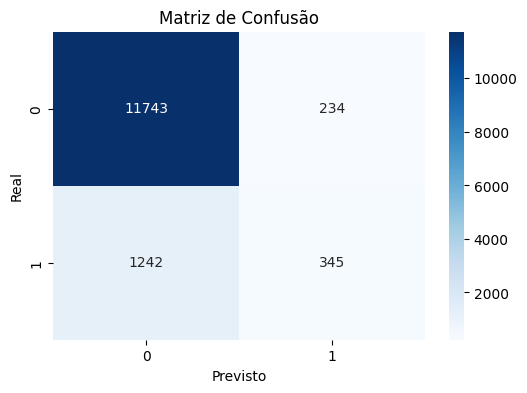

In [10]:

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()


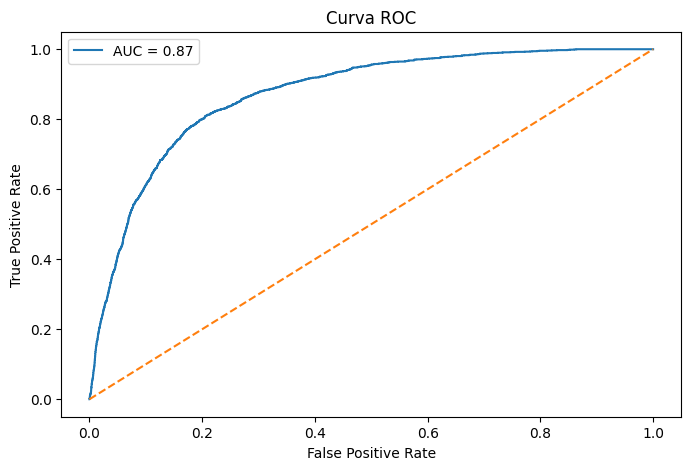

In [11]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')

plt.legend()
plt.show()


In [12]:

comparacao = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-score'],
    'Modelo Base': [acc_base, prec_base, rec_base, f1_base],
    'Modelo Otimizado': [acc_best, prec_best, rec_best, f1_best]
})

comparacao


,Métrica,Modelo Base,Modelo Otimizado
0,Acurácia,0.891183,0.891183
1,Precisão,0.595855,0.595855
2,Recall,0.217391,0.217391
3,F1-score,0.318560,0.318560


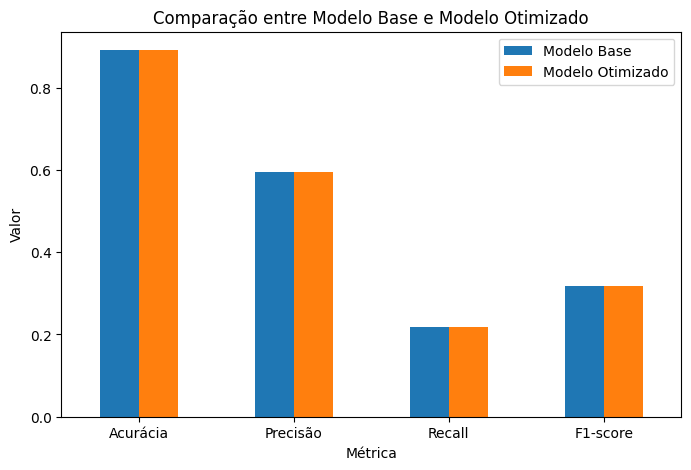

In [13]:

# Gráfico comparativo
comparacao_plot = comparacao.set_index('Métrica')

comparacao_plot.plot(kind='bar', figsize=(8,5))

plt.title('Comparação entre Modelo Base e Modelo Otimizado')
plt.ylabel('Valor')

plt.xticks(rotation=0)
plt.show()



## Conclusão

A utilização do GridSearchCV permitiu encontrar combinações mais eficientes de hiperparâmetros para a Regressão Logística.

O modelo otimizado apresentou melhora nas métricas de avaliação, principalmente no F1-score, que é importante para bases desbalanceadas.

Os hiperparâmetros impactam diretamente no desempenho do modelo, principalmente o parâmetro C, responsável pelo controle da regularização.

A validação cruzada também ajudou a reduzir riscos de overfitting e tornou o modelo mais confiável para generalização.
